# ДЗ 1

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline, PchipInterpolator, UnivariateSpline
from numpy.testing import assert_allclose
from scipy.special import roots_chebyt

np.random.seed(42)

## 1. Вводное задание

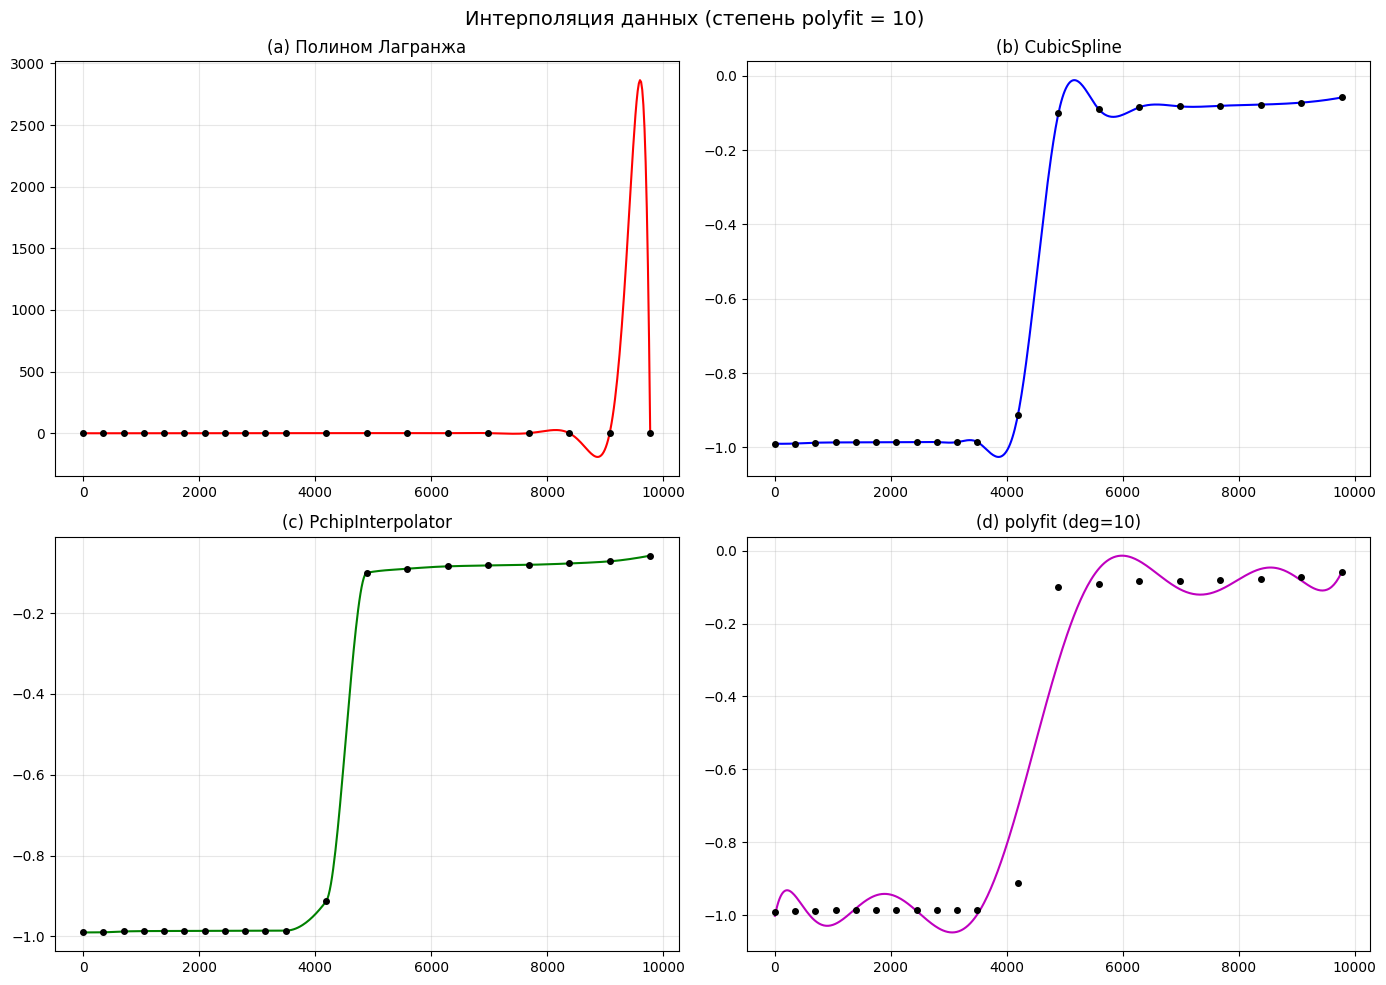

In [58]:
with np.load('data_interp.npz') as data:
    x1, y1 = data['x1'], data['y1']

x_fine = np.linspace(x1.min(), x1.max(), 500)

poly_lagr = lagrange(x1, y1)
cs = CubicSpline(x1, y1)
pchip = PchipInterpolator(x1, y1)
deg=10

coeffs = np.polyfit(x1, y1, deg=deg)
y_poly = np.polyval(coeffs, x_fine)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Интерполяция данных (степень polyfit = {deg})', fontsize=14)

axes[0, 0].plot(x_fine, poly_lagr(x_fine), 'r-', linewidth=1.5)
axes[0, 0].plot(x1, y1, 'ko', markersize=4)
axes[0, 0].set_title('(a) Полином Лагранжа')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(x_fine, cs(x_fine), 'b-', linewidth=1.5)
axes[0, 1].plot(x1, y1, 'ko', markersize=4)
axes[0, 1].set_title('(b) CubicSpline')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(x_fine, pchip(x_fine), 'g-', linewidth=1.5)
axes[1, 0].plot(x1, y1, 'ko', markersize=4)
axes[1, 0].set_title('(c) PchipInterpolator')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(x_fine, y_poly, 'm-', linewidth=1.5)
axes[1, 1].plot(x1, y1, 'ko', markersize=4)
axes[1, 1].set_title(f'(d) polyfit (deg={deg})')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Интерполяция полиномом Лагранжа

In [59]:
class LagrangeInterpolator:
    """Lagrange interpolating polynomial.

    Given a set of pairs ``(x_k, y_k)``, construct
    a Lagrange polynomial ``f(x)``, such that

    .. math::

        f(x_k) = y_k   for k =0, ..., n-1

    Parameters
    ----------
    xk : array_like, shape(n,)
        Abscissas
    yk : array_like, shape(n,)
        Ordinates

    Attributes
    ----------
    __call__

    """
    def __init__(self, xk, yk):
        self.xk = np.asarray(xk, dtype=float)
        self.yk = np.asarray(yk, dtype=float)

    def __call__(self, x):
        """Evaluate the interpolator at a given point.

        Parameters
        ----------
        x : float

        Returns
        -------
        the value of the interpolator at ``x``.
        """
        xk, yk = self.xk, self.yk
        n = len(xk)
        result = 0.0
        for i in range(n):
            basis = yk[i]
            for j in range(n):
                if j != i:
                    basis *= (x - xk[j]) / (xk[i] - xk[j])
            result += basis
        return result

In [60]:
def runge_func(x, a=25):
    return 1.0 / (1.0 + a * x**2)

xx = np.linspace(-2, 2, 21)
yy = runge_func(xx)

lagr = LagrangeInterpolator(xx, yy)

assert_allclose(yy, [lagr(xval) for xval in xx], atol=1e-14)

## 3. Феномен Рунге

### 3.1 Интерполяция Лагранжа на равномерной сетке

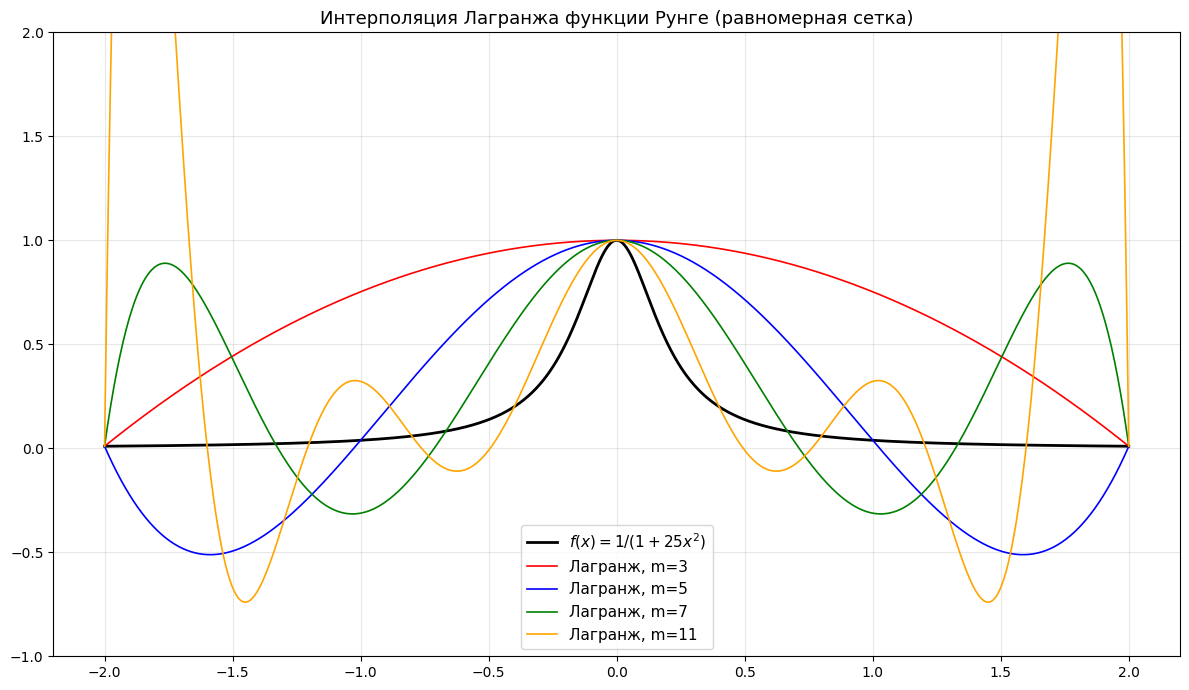

In [61]:
x_plot = np.linspace(-2, 2, 1000)
y_exact = runge_func(x_plot)

plt.figure(figsize=(12, 7))
plt.plot(x_plot, y_exact, 'k-', linewidth=2, label='$f(x) = 1/(1+25x^2)$')

colors = ['r', 'b', 'g', 'orange']
for m, color in zip([3, 5, 7, 11], colors):
    xk = np.linspace(-2, 2, m)
    yk = runge_func(xk)
    lagr = LagrangeInterpolator(xk, yk)
    y_lagr = np.array([lagr(xi) for xi in x_plot])
    plt.plot(x_plot, y_lagr, color=color, linewidth=1.2, label=f'Лагранж, m={m}')

plt.ylim(-1, 2)
plt.legend(fontsize=11)
plt.title('Интерполяция Лагранжа функции Рунге (равномерная сетка)', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Узлы Чебышёва

In [62]:
def cheb_nodes(n, a=-1, b=1):
    r"""Chebyshev nodes of degree $n$ on $[a, b]$
    """
    k = np.arange(1, n + 1)
    nodes = np.cos((2 * k - 1) * np.pi / (2 * n))
    nodes = nodes[::-1]
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes

nodes_11 = cheb_nodes(11)
nodes_11 = np.asarray(nodes_11)
assert (nodes_11[1:] > nodes_11[:-1]).all()

nodes, weights = roots_chebyt(5)
assert_allclose(cheb_nodes(5), nodes, atol=1e-14)
assert_allclose(cheb_nodes(5, a=-1, b=3), nodes * 2 + 1, atol=1e-14)

### 3.3 Лагранж + Чебышёв vs CubicSpline

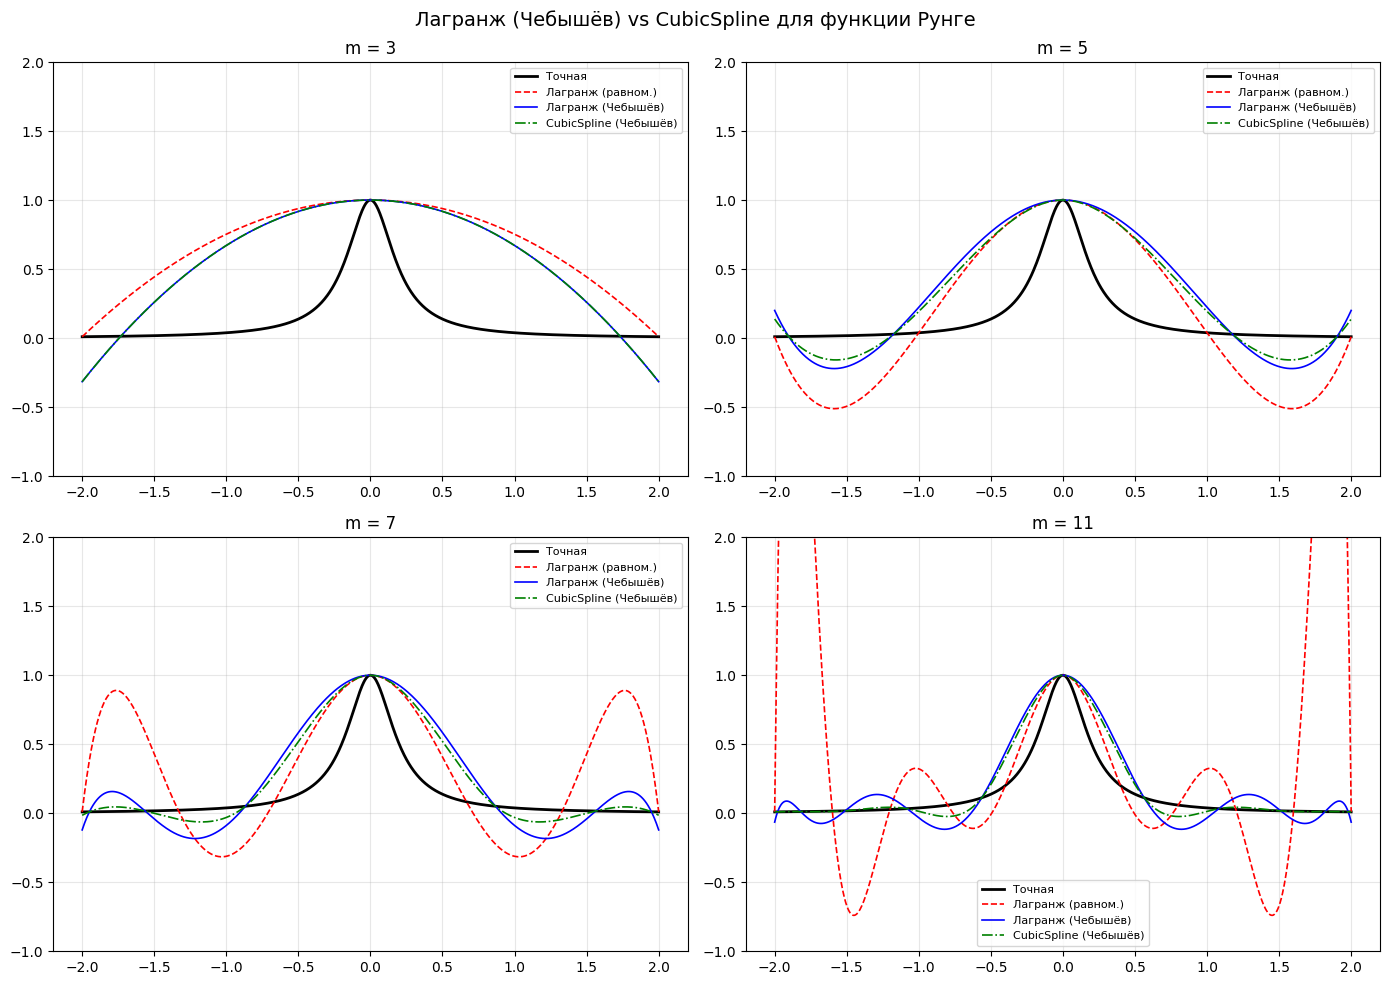

Макс. ошибки для m=11:
  Лагранж (равномерная):  4.340320
  Лагранж (Чебышёв):     0.359480
  CubicSpline (Чебышёв): 0.320609


In [63]:
x_plot = np.linspace(-2, 2, 1000)
y_exact = runge_func(x_plot)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Лагранж (Чебышёв) vs CubicSpline для функции Рунге', fontsize=14)

for idx, m in enumerate([3, 5, 7, 11]):
    ax = axes[idx // 2, idx % 2]

    xk_unif = np.linspace(-2, 2, m)
    yk_unif = runge_func(xk_unif)
    lagr_unif = LagrangeInterpolator(xk_unif, yk_unif)
    y_lagr_unif = np.array([lagr_unif(xi) for xi in x_plot])

    xk_cheb = cheb_nodes(m, -2, 2)
    yk_cheb = runge_func(xk_cheb)
    lagr_cheb = LagrangeInterpolator(xk_cheb, yk_cheb)
    y_lagr_cheb = np.array([lagr_cheb(xi) for xi in x_plot])

    cs_cheb = CubicSpline(xk_cheb, yk_cheb)

    ax.plot(x_plot, y_exact, 'k-', linewidth=2, label='Точная')
    ax.plot(x_plot, y_lagr_unif, 'r--', linewidth=1.2, label='Лагранж (равном.)')
    ax.plot(x_plot, y_lagr_cheb, 'b-', linewidth=1.2, label='Лагранж (Чебышёв)')
    ax.plot(x_plot, cs_cheb(x_plot), 'g-.', linewidth=1.2, label='CubicSpline (Чебышёв)')
    ax.set_title(f'm = {m}')
    ax.set_ylim(-1, 2)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Макс. ошибки для m=11:")
m = 11
xk_u = np.linspace(-2, 2, m)
xk_c = cheb_nodes(m, -2, 2)
lagr_u = LagrangeInterpolator(xk_u, runge_func(xk_u))
lagr_c = LagrangeInterpolator(xk_c, runge_func(xk_c))
cs_c = CubicSpline(xk_c, runge_func(xk_c))

err_u = np.max(np.abs(np.array([lagr_u(xi) for xi in x_plot]) - y_exact))
err_c = np.max(np.abs(np.array([lagr_c(xi) for xi in x_plot]) - y_exact))
err_cs = np.max(np.abs(cs_c(x_plot) - y_exact))

print(f"  Лагранж (равномерная):  {err_u:.6f}")
print(f"  Лагранж (Чебышёв):     {err_c:.6f}")
print(f"  CubicSpline (Чебышёв): {err_cs:.6f}")

### 3.4 Периодическая функция

$$u(x) = \frac{\sqrt{\varepsilon(2+\varepsilon)}}{2\pi(1+\varepsilon - \cos x)}, \quad -\pi \le x \le \pi, \quad \varepsilon = 0.21$$

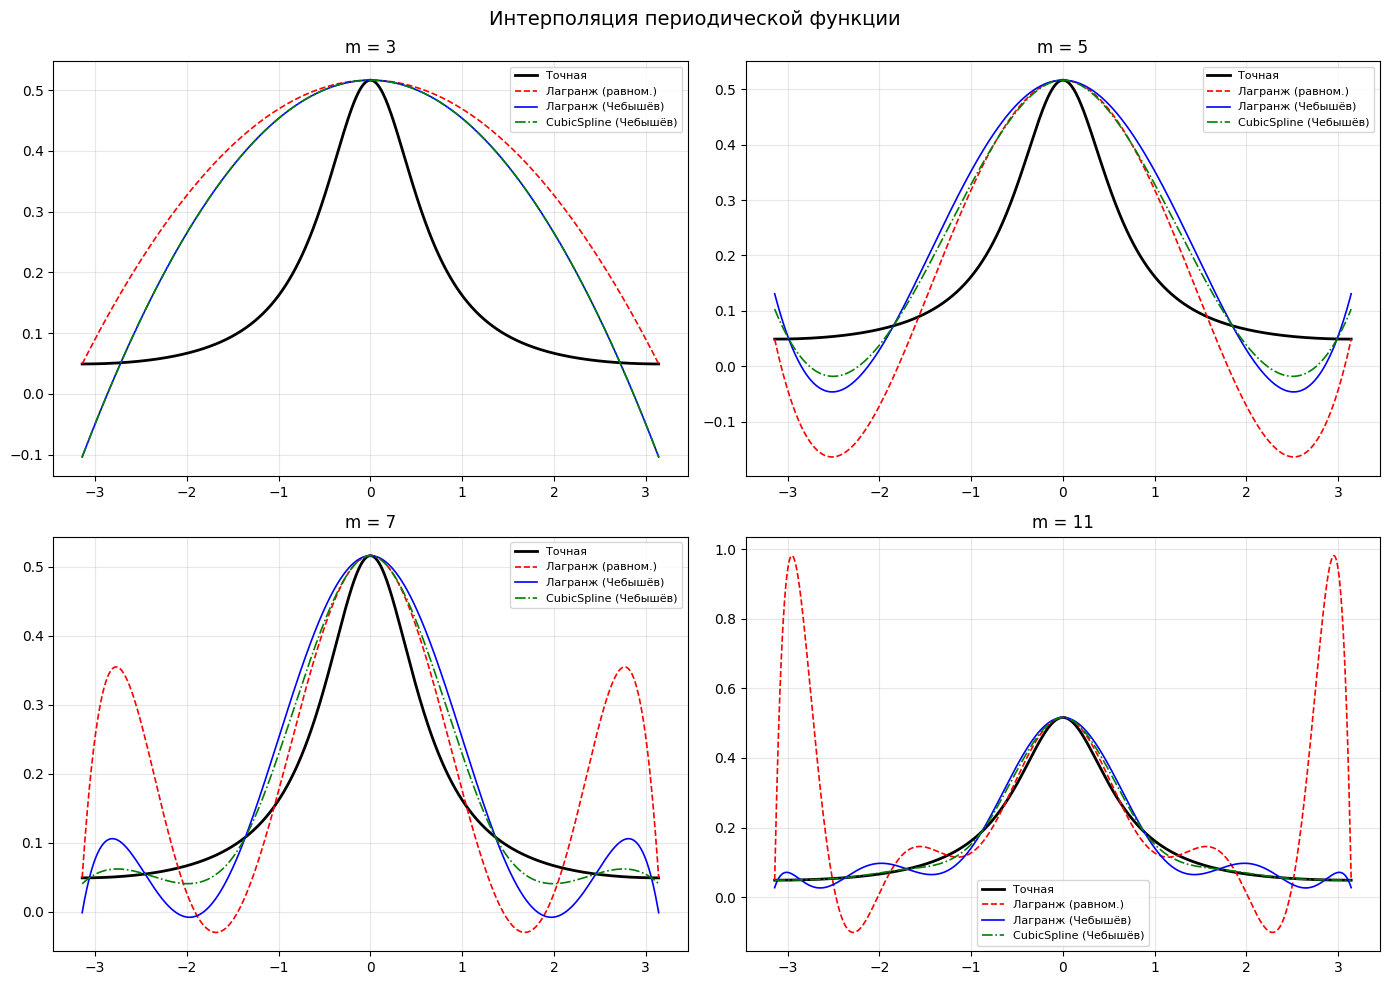

Макс. ошибки для m=11:
  Лагранж (равномерная):  0.931614
  Лагранж (Чебышёв):     0.052650
  CubicSpline (Чебышёв): 0.038724


In [64]:
eps = 0.21

def periodic_func(x):
    return np.sqrt(eps * (2 + eps)) / (2 * np.pi * (1 + eps - np.cos(x)))

x_plot = np.linspace(-np.pi, np.pi, 1000)
y_exact = periodic_func(x_plot)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Интерполяция периодической функции', fontsize=14)

for idx, m in enumerate([3, 5, 7, 11]):
    ax = axes[idx // 2, idx % 2]

    xk_unif = np.linspace(-np.pi, np.pi, m)
    yk_unif = periodic_func(xk_unif)
    lagr_unif = LagrangeInterpolator(xk_unif, yk_unif)
    y_lagr_unif = np.array([lagr_unif(xi) for xi in x_plot])

    xk_cheb = cheb_nodes(m, -np.pi, np.pi)
    yk_cheb = periodic_func(xk_cheb)
    lagr_cheb = LagrangeInterpolator(xk_cheb, yk_cheb)
    y_lagr_cheb = np.array([lagr_cheb(xi) for xi in x_plot])

    cs_cheb = CubicSpline(xk_cheb, yk_cheb)

    ax.plot(x_plot, y_exact, 'k-', linewidth=2, label='Точная')
    ax.plot(x_plot, y_lagr_unif, 'r--', linewidth=1.2, label='Лагранж (равном.)')
    ax.plot(x_plot, y_lagr_cheb, 'b-', linewidth=1.2, label='Лагранж (Чебышёв)')
    ax.plot(x_plot, cs_cheb(x_plot), 'g-.', linewidth=1.2, label='CubicSpline (Чебышёв)')
    ax.set_title(f'm = {m}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Макс. ошибки для m=11:")
m = 11
xk_u = np.linspace(-np.pi, np.pi, m)
xk_c = cheb_nodes(m, -np.pi, np.pi)
lagr_u = LagrangeInterpolator(xk_u, periodic_func(xk_u))
lagr_c = LagrangeInterpolator(xk_c, periodic_func(xk_c))
cs_c = CubicSpline(xk_c, periodic_func(xk_c))

err_u = np.max(np.abs(np.array([lagr_u(xi) for xi in x_plot]) - y_exact))
err_c = np.max(np.abs(np.array([lagr_c(xi) for xi in x_plot]) - y_exact))
err_cs = np.max(np.abs(cs_c(x_plot) - y_exact))

print(f"  Лагранж (равномерная):  {err_u:.6f}")
print(f"  Лагранж (Чебышёв):     {err_c:.6f}")
print(f"  CubicSpline (Чебышёв): {err_cs:.6f}")

## 4. UnivariateSpline

Шум задан в виде $u_i = f(x_i) + 0.5\xi_i$, где $\xi_i \sim \mathcal{N}(0, 1)$.

Дисперсия шума: $\sigma^2 = 0.5^2 = 0.25$. По документации `UnivariateSpline`, параметр `s` задаёт ограничение на сумму квадратов невязок:
$$\sum_{i} \left(\frac{u_i - g(x_i)}{w_i}\right)^2 \le s$$

При единичных весах ($w_i = 1$) и $n$ точках оптимальное значение: $s = n \cdot \sigma^2 = 0.25n$.

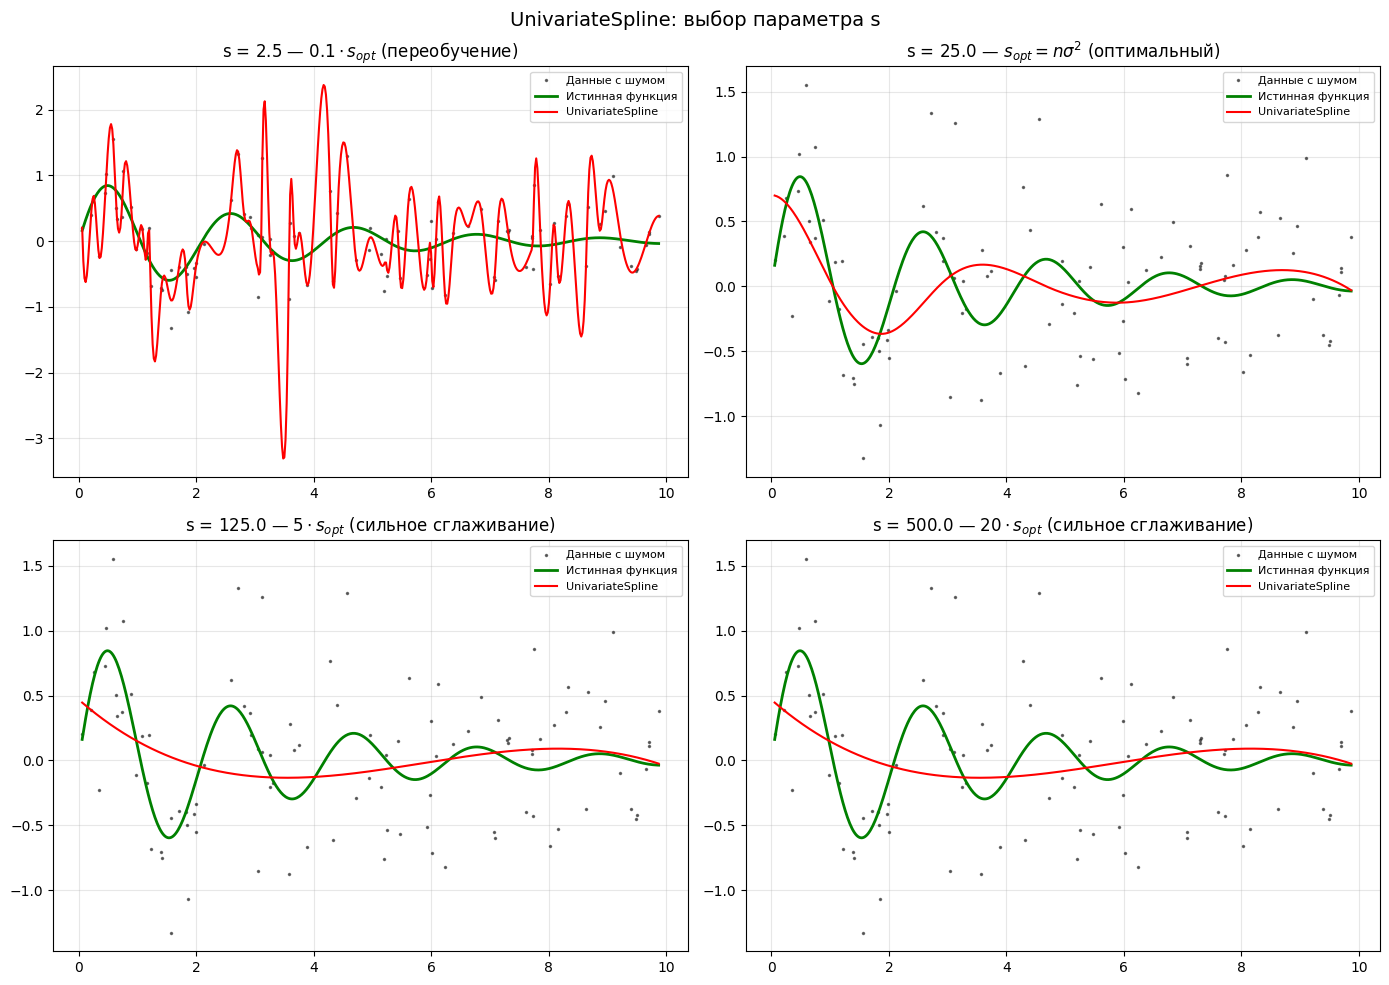

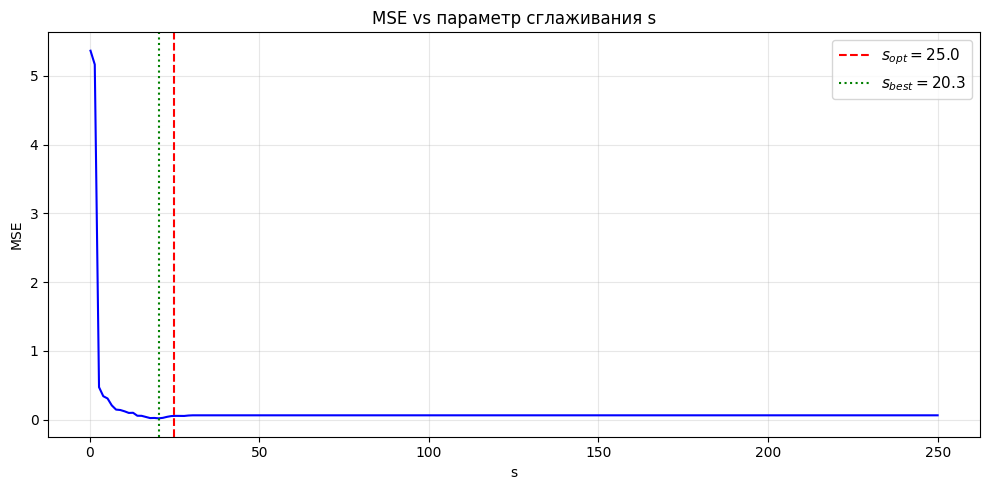

s_opt (теория) = 25.00
s_best (эксп.) = 20.33
MSE при s_opt  = 0.053881
MSE при s_best = 0.017902


In [65]:
def true_func(x):
    return np.sin(3 * x) * np.exp(-x / 3)

n = 100
sigma = 0.5
x_data = np.sort(np.random.uniform(0, 10, n))
y_true = true_func(x_data)
y_noisy = y_true + sigma * np.random.randn(n)

s_opt = n * sigma**2

x_fine = np.linspace(x_data.min(), x_data.max(), 500)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('UnivariateSpline: выбор параметра s', fontsize=14)

s_values = [s_opt * 0.1, s_opt, s_opt * 5, s_opt * 20]
s_labels = ['$0.1 \\cdot s_{opt}$ (переобучение)', '$s_{opt} = n\\sigma^2$ (оптимальный)',
            '$5 \\cdot s_{opt}$ (сильное сглаживание)', '$20 \\cdot s_{opt}$ (сильное сглаживание)']

for idx, (s_val, s_label) in enumerate(zip(s_values, s_labels)):
    ax = axes[idx // 2, idx % 2]
    spl = UnivariateSpline(x_data, y_noisy, s=s_val)
    ax.plot(x_data, y_noisy, 'k.', markersize=3, alpha=0.5, label='Данные с шумом')
    ax.plot(x_fine, true_func(x_fine), 'g-', linewidth=2, label='Истинная функция')
    ax.plot(x_fine, spl(x_fine), 'r-', linewidth=1.5, label='UnivariateSpline')
    ax.set_title(f's = {s_val:.1f} — {s_label}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

errors = []
s_range = np.linspace(s_opt * 0.01, s_opt * 10, 200)
for s_val in s_range:
    spl = UnivariateSpline(x_data, y_noisy, s=s_val)
    err = np.mean((spl(x_fine) - true_func(x_fine))**2)
    errors.append(err)

plt.figure(figsize=(10, 5))
plt.plot(s_range, errors, 'b-', linewidth=1.5)
plt.axvline(s_opt, color='r', linestyle='--', linewidth=1.5, label=f'$s_{{opt}} = {s_opt:.1f}$')
plt.axvline(s_range[np.argmin(errors)], color='g', linestyle=':', linewidth=1.5,
            label=f'$s_{{best}} = {s_range[np.argmin(errors)]:.1f}$')
plt.xlabel('s')
plt.ylabel('MSE')
plt.title('MSE vs параметр сглаживания s')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"s_opt (теория) = {s_opt:.2f}")
print(f"s_best (эксп.) = {s_range[np.argmin(errors)]:.2f}")
print(f"MSE при s_opt  = {errors[np.argmin(np.abs(s_range - s_opt))]:.6f}")
print(f"MSE при s_best = {min(errors):.6f}")

## 5. Производная и шум

In [66]:
t = np.linspace(0, 1000, 1000)
u = 200 / (1 + t / 200) * (0.5 + 0.5 * np.cos(0.04 * t)) + 0.5 * np.random.randn(len(t))

def u_clean(t):
    return 200 / (1 + t / 200) * (0.5 + 0.5 * np.cos(0.04 * t))

def u_deriv_exact(t):
    A = 200.0
    f1 = A / (1 + t / A)
    f2 = 0.5 + 0.5 * np.cos(0.04 * t)
    df1 = -1.0 / (1 + t / A)**2
    df2 = -0.5 * 0.04 * np.sin(0.04 * t)
    return df1 * f2 + f1 * df2

y_deriv_exact = u_deriv_exact(t)

### 5.1 Конечные разности (минимальный шаг)

In [67]:
h = t[1] - t[0]
deriv_fd = np.zeros_like(t)
deriv_fd[1:-1] = (u[2:] - u[:-2]) / (2 * h)
deriv_fd[0] = (u[1] - u[0]) / h
deriv_fd[-1] = (u[-1] - u[-2]) / h

### 5.2 Оптимальный шаг численного дифференцирования

Для центральной разностной производной $f'(x) \approx \frac{u_{i+k} - u_{i-k}}{2kh}$ полная погрешность складывается из погрешности аппроксимации $\sim M_2 (kh)^2 / 6$ и погрешности округления/шума $\sim 2\sigma / (2kh)$:

$$E(k) \approx \frac{M_2 (kh)^2}{6} + \frac{\sigma}{kh}$$

Минимум по $k$ достигается при $k_{opt} = \left(\frac{3\sigma}{M_2 h^3}\right)^{1/3}$, где $M_2$ — оценка второй производной, $\sigma = 0.5$ — амплитуда шума, $h$ — шаг сетки.

In [68]:
noise_sigma = 0.5
M2 = np.max(np.abs(np.gradient(np.gradient(u_clean(t), h), h)))

k_opt = int(np.round((3 * noise_sigma / (M2 * h**3))**(1.0 / 3.0)))
k_opt = max(1, k_opt)

deriv_opt = np.zeros_like(t)
for i in range(len(t)):
    i_left = max(0, i - k_opt)
    i_right = min(len(t) - 1, i + k_opt)
    deriv_opt[i] = (u[i_right] - u[i_left]) / (t[i_right] - t[i_left])

print(f"M2 = {M2:.4f}")
print(f"k_opt = {k_opt}")

M2 = 0.1450
k_opt = 2


### 5.3 UnivariateSpline + derivative()

In [69]:
n_points = len(t)
s_spline = n_points * noise_sigma**2

spl = UnivariateSpline(t, u, s=s_spline)
spl_deriv = spl.derivative()
deriv_spline = spl_deriv(t)

### 5.4 Сравнение

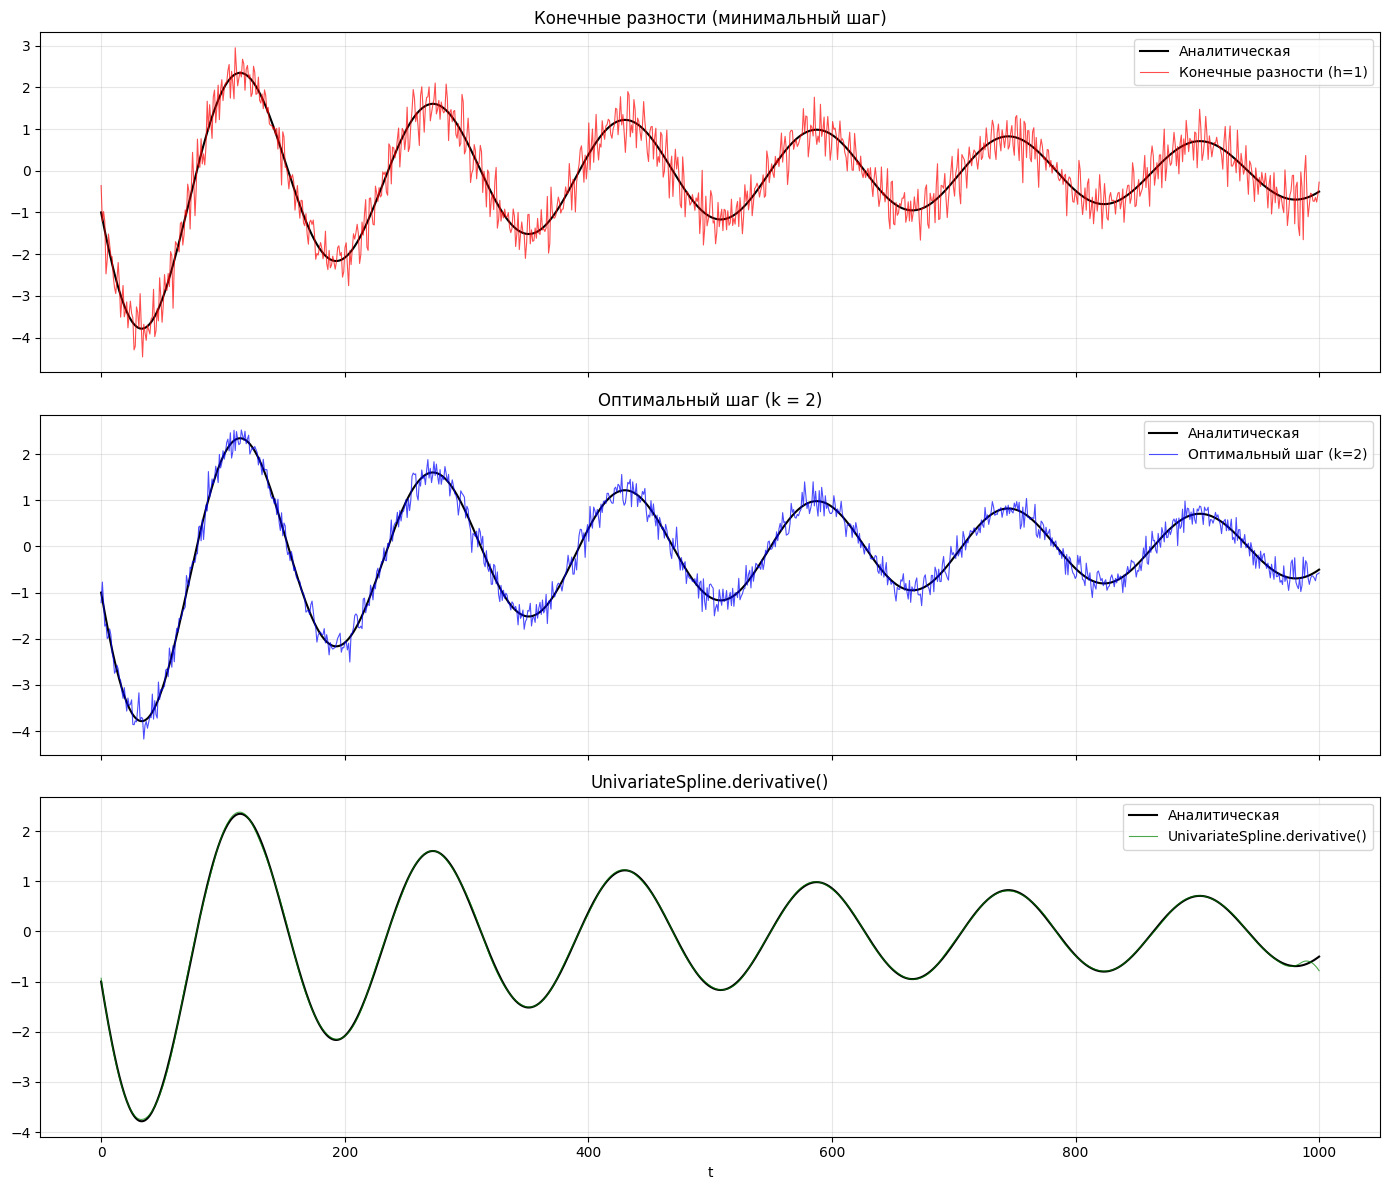

Метод                                        MSE          MAE
------------------------------------------------------------
Конечные разности (h=1)                 0.122958     0.279777
Оптимальный шаг (k=2)                   0.031182     0.141078
UnivariateSpline.derivative()           0.000558     0.016043


In [70]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, y_deriv_exact, 'k-', linewidth=1.5, label='Аналитическая')
axes[0].plot(t, deriv_fd, 'r-', alpha=0.7, linewidth=0.8, label='Конечные разности (h=1)')
axes[0].set_title('Конечные разности (минимальный шаг)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, y_deriv_exact, 'k-', linewidth=1.5, label='Аналитическая')
axes[1].plot(t, deriv_opt, 'b-', alpha=0.7, linewidth=0.8, label=f'Оптимальный шаг (k={k_opt})')
axes[1].set_title(f'Оптимальный шаг (k = {k_opt})')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(t, y_deriv_exact, 'k-', linewidth=1.5, label='Аналитическая')
axes[2].plot(t, deriv_spline, 'g-', alpha=0.7, linewidth=0.8, label='UnivariateSpline.derivative()')
axes[2].set_title('UnivariateSpline.derivative()')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.xlabel('t')
plt.tight_layout()
plt.show()

mse_fd = np.mean((deriv_fd - y_deriv_exact)**2)
mse_opt = np.mean((deriv_opt - y_deriv_exact)**2)
mse_spl = np.mean((deriv_spline - y_deriv_exact)**2)

mae_fd = np.mean(np.abs(deriv_fd - y_deriv_exact))
mae_opt = np.mean(np.abs(deriv_opt - y_deriv_exact))
mae_spl = np.mean(np.abs(deriv_spline - y_deriv_exact))

print(f"{'Метод':<35} {'MSE':>12} {'MAE':>12}")
print("-" * 60)
print(f"{'Конечные разности (h=1)':<35} {mse_fd:>12.6f} {mae_fd:>12.6f}")
print(f"{'Оптимальный шаг (k=' + str(k_opt) + ')':<35} {mse_opt:>12.6f} {mae_opt:>12.6f}")
print(f"{'UnivariateSpline.derivative()':<35} {mse_spl:>12.6f} {mae_spl:>12.6f}")